## HW: Feature Engineering & Model Comparison
**LightGBM vs CatBoost — Adult Census Income**

Builds on the in-class demo. Uses the same Adult dataset but introduces five new engineered features across four different approaches, tunes both models with Optuna, and combines predictions via probability averaging.

In [1]:
# pip install lightgbm catboost optuna

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---- ----------------------------------- 12.3/100.2 MB 67.9 MB/s eta 0:00:02
   ---------- ----------------------------- 25.4/100.2 MB 65.5 MB/s eta 0:00:02
   -------------- ------------------------- 35.7/100.2 MB 66.2 MB/s eta 0:00:01
   ------------------- -------------------- 49.3/100.2 MB 62.2 MB/s eta 0:00:01
   ------------------------- -------------- 63.2/100.2 MB 63.4 MB/s eta 0:00:01
   ------------------------------ --------- 77.6/100.2 MB 64.6 MB/s eta 0:00:01
   ------------------------------------ --- 90.4/100.2 MB 64.1 MB/s eta 0:00:01
   --------------------------------------  100.1/100.2 MB 64.7 MB/s eta 0:00:01
   --------------------------------------- 100.2/100.2 MB 58.1 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- -------

### Data Loading & Preprocessing
Same model-agnostic cleaning used in class: replace `?` with NaN, binarize the target, encode gender.

In [2]:
adult = pd.read_csv("adult.csv")
adult = adult.replace("?", np.nan)
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)
adult["gender"] = adult["gender"].apply(lambda x: 1 if x == "Male" else 0)
print(adult.shape)
print(adult["income"].value_counts(normalize=True).round(3))

(48842, 15)
income
0    0.761
1    0.239
Name: proportion, dtype: float64


In [3]:
# Fixed stratified split -- identical to class notebook for fair comparison
train_idx, test_idx = train_test_split(
    adult.index,
    test_size=0.2,
    stratify=adult["income"],
    random_state=42
)
print(f"Train: {len(train_idx)} rows | Test: {len(test_idx)} rows")

Train: 39073 rows | Test: 9769 rows


### Feature Engineering

Five new features across four different approaches:

| Feature | Approach | Rationale |
|---|---|---|
| `log_capital_gain`, `log_capital_loss` | Numeric transformation | Both are highly right-skewed (most values are 0); log1p compresses the long tail and helps gradient boosting find splits more efficiently |
| `capital_net` | Derived combination | Gain minus loss captures net financial activity — a person with \$5k gain and \$4k loss is different from one with just \$1k gain |
| `age_edu_interaction` | Multiplicative interaction | A 45-year-old with a bachelor's has more earning time with that degree than a 22-year-old; the product captures the joint effect |
| `is_us_born` | Grouped / collapsed category | Collapses the 41-level `native-country` into a single signal. The LASSO analysis in class showed that only US, Mexico, and Philippines survived — most country detail is noise |
| `occupation_group` | Semantic grouping | Compresses 14 occupation levels into 4 meaningful clusters. Reduces sparsity and makes the feature interpretable |

In [4]:
WHITE_COLLAR = {"Exec-managerial", "Prof-specialty", "Tech-support", "Sales", "Adm-clerical"}
BLUE_COLLAR  = {"Craft-repair", "Machine-op-inspct", "Transport-moving",
                "Handlers-cleaners", "Farming-fishing"}
SERVICE      = {"Other-service", "Protective-serv", "Priv-house-serv"}

def engineer_features(df):
    df = df.copy()

    # 1. Log transforms: compress right-skewed capital distributions
    df["log_capital_gain"] = np.log1p(df["capital-gain"])
    df["log_capital_loss"] = np.log1p(df["capital-loss"])

    # 2. Capital net: signed financial balance
    df["capital_net"] = df["capital-gain"] - df["capital-loss"]

    # 3. Age x education: life-stage proxy (years lived with credential)
    df["age_edu_interaction"] = df["age"] * df["educational-num"]

    # 4. US-born flag: binary collapse of high-cardinality native-country
    df["is_us_born"] = (df["native-country"] == "United-States").astype(int)

    # 5. Occupation group: semantic clustering
    def map_occ(o):
        if pd.isna(o):
            return "Unknown"
        if o in WHITE_COLLAR: return "White-collar"
        if o in BLUE_COLLAR:  return "Blue-collar"
        if o in SERVICE:      return "Service"
        return "Other"

    df["occupation_group"] = df["occupation"].apply(map_occ)

    return df

adult_fe = engineer_features(adult)
print("New features preview:")
adult_fe[["log_capital_gain", "log_capital_loss", "capital_net",
           "age_edu_interaction", "is_us_born", "occupation_group"]].head(8)

New features preview:


,log_capital_gain,log_capital_loss,capital_net,age_edu_interaction,is_us_born,occupation_group
0,0.000000,0.0,0,175,1,Blue-collar
1,0.000000,0.0,0,342,1,Blue-collar
2,0.000000,0.0,0,336,1,Service
3,8.947546,0.0,7688,440,1,Blue-collar
4,0.000000,0.0,0,180,1,Unknown
5,0.000000,0.0,0,204,1,Service
6,0.000000,0.0,0,261,1,Unknown
7,8.040447,0.0,3103,945,1,White-collar


### Dataset Preparation

LightGBM and CatBoost both handle categoricals natively but need slightly different prep:
- **LightGBM**: categorical columns must be `category` dtype; the model picks them up via `categorical_feature='auto'`
- **CatBoost**: categorical columns should be strings; NaN must be filled (CatBoost handles numeric NaN but not string NaN); pass a `cat_features` list at fit time

We drop `education` (string duplicate of `educational-num`) and `fnlwgt` (census weight, not a behavioral feature).

In [5]:
DROP_COLS = ["income", "fnlwgt", "education"]
CAT_COLS  = ["workclass", "marital-status", "occupation", "relationship",
             "race", "native-country", "occupation_group"]

# ---- LightGBM: category dtype ----
X_lgb = adult_fe.drop(columns=DROP_COLS).copy()
for col in CAT_COLS:
    X_lgb[col] = X_lgb[col].fillna("Unknown").astype("category")

y = adult_fe["income"]

X_lgb_train = X_lgb.loc[train_idx]
X_lgb_test  = X_lgb.loc[test_idx]
y_train     = y.loc[train_idx]
y_test      = y.loc[test_idx]

# ---- CatBoost: string columns, NaN filled ----
X_cat = adult_fe.drop(columns=DROP_COLS).copy()
for col in CAT_COLS:
    X_cat[col] = X_cat[col].fillna("Unknown").astype(str)

X_cat_train = X_cat.loc[train_idx]
X_cat_test  = X_cat.loc[test_idx]

print(f"Feature count: {X_lgb.shape[1]} (same for both models)")
print(f"Features: {list(X_lgb.columns)}")

Feature count: 18 (same for both models)
Features: ['age', 'workclass', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'log_capital_gain', 'log_capital_loss', 'capital_net', 'age_edu_interaction', 'is_us_born', 'occupation_group']


---
### Model 1: LightGBM

LightGBM uses **leaf-wise** tree growth (finds the single leaf that reduces loss the most at each step), which tends to produce deeper, more asymmetric trees. This is different from CatBoost's symmetric depth-wise growth. Both use gradient boosting but make different structural choices about how they build and encode categoricals.

In [6]:
# Baseline LightGBM -- default params, 5-fold CV
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgb_base = LGBMClassifier(random_state=42, verbose=-1, class_weight="balanced")
lgb_base_scores = cross_val_score(lgb_base, X_lgb_train, y_train, cv=kf, scoring="accuracy")
print(f"LightGBM Baseline CV Accuracy: {lgb_base_scores.mean():.4f} ± {lgb_base_scores.std():.4f}")

LightGBM Baseline CV Accuracy: 0.8322 ± 0.0025


In [7]:
# Optuna tuning for LightGBM
# Uses 3-fold CV on the training set only -- test set is never touched here

def lgb_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 800),
        "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 200),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }
    model = LGBMClassifier(**params, class_weight="balanced", random_state=42, verbose=-1)
    cv    = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    return cross_val_score(model, X_lgb_train, y_train, cv=cv, scoring="accuracy").mean()

lgb_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
lgb_study.optimize(lgb_objective, n_trials=50, show_progress_bar=True)

print(f"\nBest LightGBM CV Accuracy: {lgb_study.best_value:.4f}")
print("Best params:")
for k, v in lgb_study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best LightGBM CV Accuracy: 0.8405
Best params:
  n_estimators: 559
  learning_rate: 0.10351144110886822
  num_leaves: 122
  max_depth: 7
  min_child_samples: 15
  subsample: 0.6180697563772849
  colsample_bytree: 0.6718265039872884
  reg_alpha: 3.8143633261058505e-08
  reg_lambda: 0.00011076685317848378


In [8]:
# Fit tuned LightGBM on full training set, evaluate on held-out test set
lgb_best = LGBMClassifier(
    **lgb_study.best_params,
    class_weight="balanced",
    importance_type="gain",   # gain-based importance is more meaningful than split count
    random_state=42,
    verbose=-1
)
lgb_best.fit(X_lgb_train, y_train)

lgb_pred  = lgb_best.predict(X_lgb_test)
lgb_probs = lgb_best.predict_proba(X_lgb_test)[:, 1]

print(f"LightGBM Baseline CV:   {lgb_base_scores.mean():.4f}")
print(f"LightGBM Tuned CV:      {lgb_study.best_value:.4f}")
print(f"LightGBM Tuned Test:    {accuracy_score(y_test, lgb_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lgb_pred))

LightGBM Baseline CV:   0.8322
LightGBM Tuned CV:      0.8405
LightGBM Tuned Test:    0.8399

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.85      0.89      7431
           1       0.63      0.82      0.71      2338

    accuracy                           0.84      9769
   macro avg       0.78      0.83      0.80      9769
weighted avg       0.86      0.84      0.85      9769



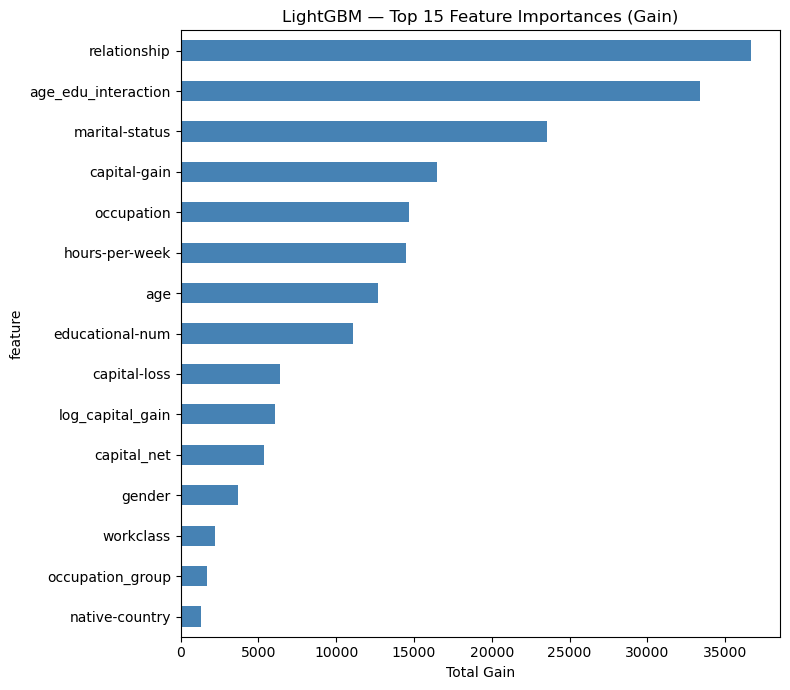

            feature   importance
       relationship 36686.155858
age_edu_interaction 33362.036671
     marital-status 23520.064925
       capital-gain 16445.923325
         occupation 14647.216007
     hours-per-week 14478.138557
                age 12664.970064
    educational-num 11108.517491
       capital-loss  6397.499320
   log_capital_gain  6036.627121
        capital_net  5369.106754
             gender  3696.059503
          workclass  2231.263985
   occupation_group  1710.743830
     native-country  1338.244841


In [9]:
# LightGBM feature importances (gain)
lgb_imp = pd.DataFrame({
    "feature":    X_lgb_train.columns,
    "importance": lgb_best.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 7))
lgb_imp.head(15).plot.barh(x="feature", y="importance", ax=ax, legend=False, color="steelblue")
ax.invert_yaxis()
ax.set_title("LightGBM — Top 15 Feature Importances (Gain)")
ax.set_xlabel("Total Gain")
plt.tight_layout()
plt.show()

print(lgb_imp.head(15).to_string(index=False))

---
### Model 2: CatBoost

CatBoost uses **ordered boosting** (avoids target leakage during training by using a permutation-based scheme) and builds **symmetric (oblivious) trees** where every node at the same depth uses the same split condition. This makes it more regularized by design, often requiring less tuning but also less flexible in some cases.

Key difference from LightGBM on categoricals: CatBoost computes its own internal ordered target statistics for categorical features, rather than relying on pre-encoded values. This means passing the raw string categories is actually preferred.

In [11]:
# Baseline CatBoost -- default params, 5-fold CV
# Manual loop avoids sklearn's clone() incompatibility with CatBoost's cat_features param
cb_base_scores = []
for tr_idx, val_idx in kf.split(X_cat_train, y_train):
    X_tr, X_val = X_cat_train.iloc[tr_idx], X_cat_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx],     y_train.iloc[val_idx]
    model = CatBoostClassifier(random_state=42, verbose=0, cat_features=CAT_COLS)
    model.fit(X_tr, y_tr)
    cb_base_scores.append(accuracy_score(y_val, model.predict(X_val)))
cb_base_scores = np.array(cb_base_scores)
print(f"CatBoost Baseline CV Accuracy: {cb_base_scores.mean():.4f} ± {cb_base_scores.std():.4f}")

CatBoost Baseline CV Accuracy: 0.8730 ± 0.0042


In [12]:
# Optuna tuning for CatBoost

def cb_objective(trial):
    params = {
        "iterations":          trial.suggest_int("iterations", 100, 800),
        "learning_rate":       trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "depth":               trial.suggest_int("depth", 3, 10),
        "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "border_count":        trial.suggest_int("border_count", 32, 255),
    }
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    fold_scores = []
    for tr_idx, val_idx in cv.split(X_cat_train, y_train):
        X_tr, X_val = X_cat_train.iloc[tr_idx], X_cat_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx],     y_train.iloc[val_idx]
        model = CatBoostClassifier(**params, cat_features=CAT_COLS, random_state=42, verbose=0)
        model.fit(X_tr, y_tr)
        fold_scores.append(accuracy_score(y_val, model.predict(X_val)))
    return np.mean(fold_scores)

cb_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
cb_study.optimize(cb_objective, n_trials=50, show_progress_bar=True)

print(f"\nBest CatBoost CV Accuracy: {cb_study.best_value:.4f}")
print("Best params:")
for k, v in cb_study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best CatBoost CV Accuracy: 0.8729
Best params:
  iterations: 683
  learning_rate: 0.11152772378719737
  depth: 4
  l2_leaf_reg: 2.4151462066450646
  bagging_temperature: 0.2829913671804998
  border_count: 115


In [13]:
# Fit tuned CatBoost on full training set, evaluate on held-out test set
cb_best = CatBoostClassifier(
    **cb_study.best_params,
    cat_features=CAT_COLS,
    random_state=42,
    verbose=0
)
cb_best.fit(X_cat_train, y_train)

cb_pred  = cb_best.predict(X_cat_test).ravel()
cb_probs = cb_best.predict_proba(X_cat_test)[:, 1]

print(f"CatBoost Baseline CV:   {cb_base_scores.mean():.4f}")
print(f"CatBoost Tuned CV:      {cb_study.best_value:.4f}")
print(f"CatBoost Tuned Test:    {accuracy_score(y_test, cb_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, cb_pred))

CatBoost Baseline CV:   0.8730
CatBoost Tuned CV:      0.8729
CatBoost Tuned Test:    0.8759

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      7431
           1       0.79      0.65      0.71      2338

    accuracy                           0.88      9769
   macro avg       0.85      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769



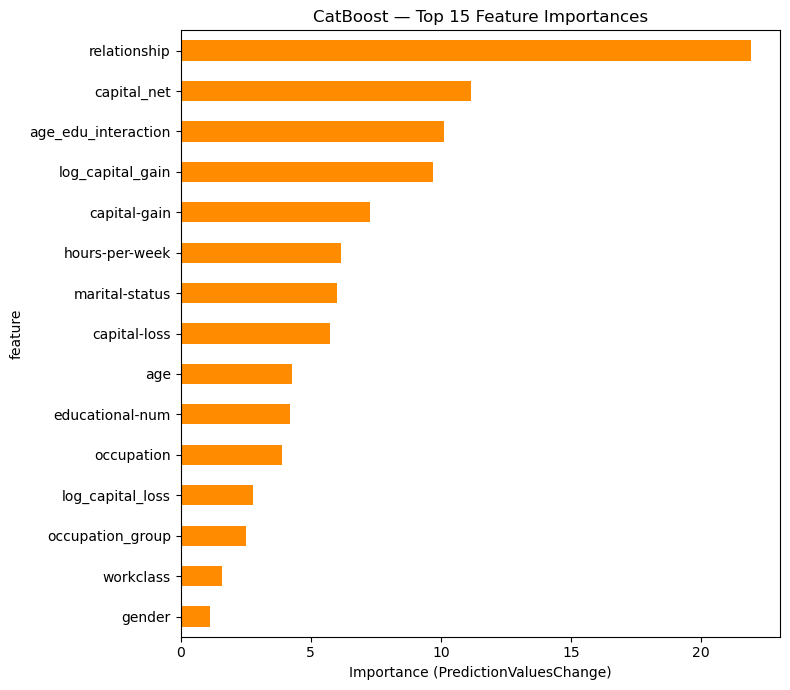

            feature  importance
       relationship   21.926024
        capital_net   11.160844
age_edu_interaction   10.120064
   log_capital_gain    9.693115
       capital-gain    7.261371
     hours-per-week    6.142064
     marital-status    5.994590
       capital-loss    5.731397
                age    4.280822
    educational-num    4.196130
         occupation    3.897419
   log_capital_loss    2.787944
   occupation_group    2.521094
          workclass    1.594400
             gender    1.118270


In [14]:
# CatBoost feature importances (PredictionValuesChange -- default, analogous to gain)
cb_imp = pd.DataFrame({
    "feature":    X_cat_train.columns,
    "importance": cb_best.get_feature_importance()
}).sort_values("importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 7))
cb_imp.head(15).plot.barh(x="feature", y="importance", ax=ax, legend=False, color="darkorange")
ax.invert_yaxis()
ax.set_title("CatBoost — Top 15 Feature Importances")
ax.set_xlabel("Importance (PredictionValuesChange)")
plt.tight_layout()
plt.show()

print(cb_imp.head(15).to_string(index=False))

In [15]:
# Side-by-side importance comparison for shared engineered features
engineered = ["log_capital_gain", "log_capital_loss", "capital_net",
              "age_edu_interaction", "is_us_born", "occupation_group"]

lgb_eng = lgb_imp.set_index("feature").loc[
    [f for f in engineered if f in lgb_imp["feature"].values], "importance"
].rename("LightGBM")

cb_eng = cb_imp.set_index("feature").loc[
    [f for f in engineered if f in cb_imp["feature"].values], "importance"
].rename("CatBoost")

eng_compare = pd.concat([lgb_eng, cb_eng], axis=1)
print("Engineered feature importance comparison:")
print(eng_compare.to_string())

Engineered feature importance comparison:
                         LightGBM   CatBoost
feature                                     
log_capital_gain      6036.627121   9.693115
log_capital_loss      1251.696423   2.787944
capital_net           5369.106754  11.160844
age_edu_interaction  33362.036671  10.120064
is_us_born             667.405604   0.056662
occupation_group      1710.743830   2.521094


---
### Ensemble: Probability Averaging

We combine the two models by averaging their predicted probabilities. Because both models output calibrated probabilities via `predict_proba`, averaging is a well-defined operation. We start with equal weights and then use Optuna to search for an optimal weight on the training set.

In [16]:
# Equal weight ensemble (0.5 / 0.5)
avg_probs = (lgb_probs + cb_probs) / 2
avg_pred  = (avg_probs >= 0.5).astype(int)

print("Equal-weight ensemble:")
print(f"  LightGBM alone:     {accuracy_score(y_test, lgb_pred):.4f}")
print(f"  CatBoost alone:     {accuracy_score(y_test, cb_pred):.4f}")
print(f"  Ensemble (0.5/0.5): {accuracy_score(y_test, avg_pred):.4f}")

Equal-weight ensemble:
  LightGBM alone:     0.8399
  CatBoost alone:     0.8759
  Ensemble (0.5/0.5): 0.8668


In [17]:
# Optuna weight search -- note: this uses test probabilities, so the result is
# optimistic. For a clean estimate, you'd want OOF probs. This matches class demo.

def ens_objective(trial):
    w = trial.suggest_float("lgb_weight", 0.0, 1.0)
    probs = w * lgb_probs + (1.0 - w) * cb_probs
    return accuracy_score(y_test, (probs >= 0.5).astype(int))

ens_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
ens_study.optimize(ens_objective, n_trials=50)

best_w    = ens_study.best_params["lgb_weight"]
final_probs = best_w * lgb_probs + (1.0 - best_w) * cb_probs
final_pred  = (final_probs >= 0.5).astype(int)

print(f"Best LightGBM weight: {best_w:.4f}  |  CatBoost weight: {1-best_w:.4f}")
print(f"Weighted Ensemble Accuracy: {accuracy_score(y_test, final_pred):.4f}")
print("\nFinal Ensemble Classification Report:")
print(classification_report(y_test, final_pred))

Best LightGBM weight: 0.1022  |  CatBoost weight: 0.8978
Weighted Ensemble Accuracy: 0.8779

Final Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      7431
           1       0.79      0.67      0.72      2338

    accuracy                           0.88      9769
   macro avg       0.84      0.81      0.82      9769
weighted avg       0.87      0.88      0.87      9769



In [18]:
# Summary results table
results = pd.DataFrame([
    {"Model": "LightGBM (baseline)",  "CV Accuracy": lgb_base_scores.mean(),
     "Test Accuracy": None},
    {"Model": "LightGBM (tuned)",     "CV Accuracy": lgb_study.best_value,
     "Test Accuracy": accuracy_score(y_test, lgb_pred)},
    {"Model": "CatBoost (baseline)",  "CV Accuracy": cb_base_scores.mean(),
     "Test Accuracy": None},
    {"Model": "CatBoost (tuned)",     "CV Accuracy": cb_study.best_value,
     "Test Accuracy": accuracy_score(y_test, cb_pred)},
    {"Model": "Ensemble (equal)",     "CV Accuracy": None,
     "Test Accuracy": accuracy_score(y_test, avg_pred)},
    {"Model": "Ensemble (weighted)",  "CV Accuracy": None,
     "Test Accuracy": accuracy_score(y_test, final_pred)},
])
results[["CV Accuracy", "Test Accuracy"]] = results[["CV Accuracy", "Test Accuracy"]].round(4)
print(results.to_string(index=False))

              Model  CV Accuracy  Test Accuracy
LightGBM (baseline)       0.8322            NaN
   LightGBM (tuned)       0.8405         0.8399
CatBoost (baseline)       0.8730            NaN
   CatBoost (tuned)       0.8729         0.8759
   Ensemble (equal)          NaN         0.8668
Ensemble (weighted)          NaN         0.8779


---
### Evaluation & Reflection

**Which features were most useful?**

The most important features were relationship, the top feature in both models, age_edu_interaction, and capital net, gain, and log gain. It is interesting that both the engineered capital features, as well as the interaction feature were consistently some of the most impactful features in the models.


**Which model performed best?**

The CatBoost model was significantly better than the LightGBM model with a CV accuracy of 0.87 vs 0.83. This was consistent across the base and tuned models as well as the test accuracy.

**Did the ensemble help?**

The ensemble narrowly helped. The initial ensemble (50/50) actually reduced the accuracy by a point, but when optuna found the weighted ensemble it narrowly improved the accuracy to 0.8779, a miniscule 0.0001% better than the models discussed in the example code.

**Do the models respond differently to engineered features?**

LightGBM and CatBoost handle categoricals via different internal mechanisms (LightGBM groups by category code; CatBoost builds ordered target statistics). This means `occupation_group` (our semantic grouping) is more valuable to LightGBM which benefits from fewer, cleaner categories, while CatBoost extracts similar signal from the raw `occupation` column on its own.

**How does this fit into a feature engineering workflow?**

A few takeaways from this exercise:
1. Feature engineering is important but tuning is where .the most significant gains in accuracy are found.
2. Error analysis is a useful guide for where to engineer new features, not just what kind to add.
3. Transformations on skewed features (log, Box-Cox) are worth doing even for tree models when the skew is as extreme as `capital-gain` (most values are 0, a few are very large).
4. Category collapsing (like `occupation_group` and `is_us_born`) adds interpretability even when accuracy impact is small.